In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from make_network import * 
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib.pyplot as plt

from model_unified_ver import run_exp
from model_unified_ver import default_params as params
import utils as utl
from analysis_of_simulation_result import * 

syn_df = pd.read_parquet(REPO_ROOT/'data/Connectivity_783.parquet')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [2]:
from scipy.stats import hmean

DATA_DIR = REPO_ROOT/'figure5/data'

def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

def calculate_network_characteristics(activation,silence,mode='sweet'):
    
    df_per_concent = {}
    for concent in silence.columns:
        if mode == 'sweet':
            slnc = silence[concent]
            act = activation[0]
            N = (slnc.loc['control'] - slnc)/slnc.loc['control']
            S = act - act.loc['control']
        else:
            slnc = silence[concent]
            act = activation[concent]
            N = (slnc - slnc.loc['control'])/slnc.loc['control']
            S = (act.loc['control'] - act)/act.loc['control']
        N = N.clip(lower=0)
        S = S.clip(lower=0)
        N, S = N.align(S)
        HM = hmean(np.vstack([N,S]))
        df = pd.DataFrame({
            'Necessity': N,
            'Sufficiency': S,
            'HM': HM
        }, index=N.index)    
        df[f'rank_v{concent}'] = df['HM'].rank(ascending=False, method='min').astype(int)
        df_per_concent[concent] = df 
    
    return df_per_concent 



### Sweet ###
# Tarsal
tarsal_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "tarsal",
)
tarsal_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "tarsal",
)


# Labellar
labial_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "labellar",
)
labial_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "labellar",
)
labial_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "labellar",
)



### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)


tarsal_sweet_df = calculate_network_characteristics(tarsal_activation_per,tarsal_screening_per,mode='sweet')
labial_sweet_df = calculate_network_characteristics(labial_activation_per,labial_screening_per,mode='sweet')
tarsal_geosmin_df = calculate_network_characteristics(tarsal_geosmin_activation_per,tarsal_geosmin_screening_per,mode='geosmin')
labial_geosmin_df = calculate_network_characteristics(labial_geosmin_activation_per,labial_geosmin_screening_per,mode='geosmin')


In [117]:
mean_data_necessity = {}
mean_data_necessity['tarsal'] = pd.concat([y['Necessity'] for x,y in tarsal_sweet_df.items()],axis=1).mean(axis=1).drop('control')
mean_data_necessity['labial'] = pd.concat([y['Necessity'] for x,y in labial_sweet_df.items()],axis=1).mean(axis=1).drop('control')

mean_data_sufficiency = {}
mean_data_sufficiency['tarsal'] = pd.concat([y['Sufficiency'] for x,y in tarsal_sweet_df.items()],axis=1).mean(axis=1).drop('control')
mean_data_sufficiency['labial'] = pd.concat([y['Sufficiency'] for x,y in labial_sweet_df.items()],axis=1).mean(axis=1).drop('control')


color_path = REPO_ROOT/'figure6/figure6C,F,L,O_Compare_necessity_exp_vs_simul/data'
color_info_all = {}
for g in ['tarsal','labial']:
    color_info_all[g] = pickle.load(open(os.path.join(color_path,f'color_info_{g}-union.pkl'),'rb'))

In [58]:
pivot_group_T = pd.read_parquet('data/firing_rate_in_each_condition_tarsal.parquet')
pivot_group_L = pd.read_parquet('data/firing_rate_in_each_condition_labial.parquet')
firing_rate_change_T = 1 - pivot_group_T['88.4Hz_82.5Hz_170Hz']/pivot_group_T['88.4Hz_82.5Hz_0Hz']
firing_rate_change_L = 1 - pivot_group_L['25.7Hz_23.5Hz_170Hz']/pivot_group_L['25.7Hz_23.5Hz_0Hz']


Necessity_T = mean_data_necessity['tarsal'].loc[firing_rate_change_T.index]
pivot_df_T  = pd.concat([firing_rate_change_T,Necessity_T],axis=1)

Necessity_L = mean_data_necessity['labial'].loc[firing_rate_change_L.index]
pivot_df_L  = pd.concat([firing_rate_change_L,Necessity_L],axis=1)



In [71]:
in_tarsal = mean_data_necessity['tarsal'].index
in_labial = mean_data_necessity['labial'].index
only_tarsal = np.setdiff1d(in_tarsal,in_labial)
only_labial = np.setdiff1d(in_labial,in_tarsal)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

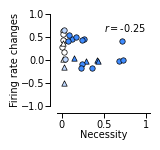

In [120]:
from scipy.stats import pearsonr
fig,ax = plt.subplots(1,1,figsize=(1.2,1.2))
Necess_in_network = []
firing_rate_change_in_network = []
X= []
Y= []
for g in Necessity_T.index:
    if color_info_all['tarsal'][int(g)] != '#777777':
        Necess_in_network.append(Necessity_T.loc[g])
        firing_rate_change_in_network.append(firing_rate_change_T.loc[g])
        if g in only_tarsal:
            ax.scatter(Necessity_T.loc[g],firing_rate_change_T.loc[g],color=color_info_all['tarsal'][int(g)],edgecolors='black',linewidths=.5,s=15,marker='^')
        else:
            ax.scatter(Necessity_T.loc[g],firing_rate_change_T.loc[g],color=color_info_all['tarsal'][int(g)],edgecolors='black',linewidths=.5,s=15)
        X.append(Necessity_T.loc[g])
        Y.append(firing_rate_change_T.loc[g])
   
        
ax.spines[['top','right']].set_visible(False)
ax.set_ylim([-1,1])
ax.set_xlim([-.1,1])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
R = pearsonr(X,Y)
ax.text(.5,.6,f'$r = ${np.round(R.statistic,2)}')
ax.set_ylabel('Firing rate changes')
ax.set_xlabel('Necessity')
ax.set_xticks([0,.5,1],[0,.5,1])
ax.set_xlim([-.05,1.05])
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('firing_rate_change_vs_Necessity_tarsal.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

PearsonRResult(statistic=-0.006571100313648765, pvalue=0.9756895205549465)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


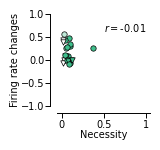

In [121]:
fig,ax = plt.subplots(1,1,figsize=(1.2,1.2))
Necess_in_network = []
firing_rate_change_in_network = []
X = []
Y = []
for g in Necessity_L.index:
    if color_info_all['labial'][int(g)] != '#777777':    
        Necess_in_network.append(Necessity_L.loc[g])
        firing_rate_change_in_network.append(firing_rate_change_L.loc[g])
        if g in only_labial:
            ax.scatter(Necessity_L.loc[g],firing_rate_change_L.loc[g],color=color_info_all['labial'][int(g)],edgecolors='black',linewidths=.5,s=15,marker='v')
        else:
            ax.scatter(Necessity_L.loc[g],firing_rate_change_L.loc[g],color=color_info_all['labial'][int(g)],edgecolors='black',linewidths=.5,s=15)
        X.append(Necessity_L.loc[g])
        Y.append(firing_rate_change_L.loc[g])


        
print(pearsonr(Necess_in_network,firing_rate_change_in_network))
        
ax.spines[['top','right']].set_visible(False)
ax.set_ylim([-1,1])
ax.set_xlim([-.1,1])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.set_xticks([0,.5,1],[0,.5,1])
ax.set_ylabel('Firing rate changes')
ax.set_xlabel('Necessity')
ax.set_xlim([-.05,1.05])

R = pearsonr(X,Y)
ax.text(.5,.6,f'$r = ${np.round(R.statistic,2)}')
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('firing_rate_change_vs_Necessity_labial.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

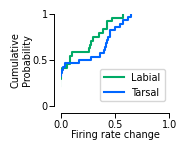

In [122]:
def plot_cdf(data, label, ax,color):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    # drawstyle='steps-post'를 사용하여 계단형 그래프로 그립니다.
    ax.plot(x, y, label=label, drawstyle='steps-post',color=color)

firing_rate_change_L_in_network = [y for x,y in zip(firing_rate_change_L.index,firing_rate_change_L.values) if color_info_all['labial'][int(x)]!='#777777']
firing_rate_change_T_in_network = [y for x,y in zip(firing_rate_change_T.index,firing_rate_change_T.values) if color_info_all['tarsal'][int(x)]!='#777777']
fig, ax = plt.subplots(1, 1, figsize=(1.4, 1.2))
plot_cdf(firing_rate_change_L_in_network, 'Labial', ax,color='#00AA66')
plot_cdf(firing_rate_change_T_in_network, 'Tarsal', ax,color='#0066FF')
ax.spines[['top', 'right']].set_visible(False)
# ax.legend()
# ylim을 1.1로 설정하면 1.0 위로 여백이 너무 커지므로, 1.05 정도로 조정하거나 생략하는 것이 좋습니다.


# fig,ax = plt.subplots(1,1,figsize=(2,2))
# sns.ecdfplot(pivot_df_L, label='Labial',ax=ax)
# sns.ecdfplot(pivot_df_T, label='Tarsal',ax=ax)

ax.set_xlabel('Firing rate change')
ax.set_ylabel('Cumulative\nProbability')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5

ax.tick_params(pad=1)
ax.set_yticks([0,.5,1],[0,.5,1])
ax.set_ylim([0,1])
ax.set_xlim([0,1])
for spine in ax.spines.values():
    spine.set_linewidth(0.7)

# Tick thickness
ax.tick_params(
    axis='both',
    width=0.7,
    pad=1
)
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('CDF_firing_rate.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

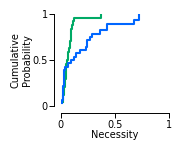

In [123]:
pivot_df_L_necessity = [y for x,y in zip(mean_data_necessity['labial'].index,mean_data_necessity['labial'].values) if color_info_all['labial'][int(x)]!='#777777' ]
pivot_df_T_necessity = [y for x,y in zip(mean_data_necessity['tarsal'].index,mean_data_necessity['tarsal'].values) if color_info_all['tarsal'][int(x)]!='#777777' ]
    
fig, ax = plt.subplots(1, 1, figsize=(1.4, 1.2))
plot_cdf(pivot_df_L_necessity, 'Labial', ax,color='#00AA66')
plot_cdf(pivot_df_T_necessity, 'Tarsal', ax,color='#0066FF')

ax.spines[['top', 'right']].set_visible(False)
# ax.legend()


ax.spines[['top','right']].set_visible(False)
ax.set_xlabel('Necessity')
ax.set_ylabel('Cumulative\nProbability')
# ax.legend(loc='lower right')
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5

ax.tick_params(pad=1)
ax.set_yticks([0,.5,1],[0,.5,1])
ax.set_xticks([0,.5,1],[0,.5,1])
ax.set_ylim([0,1])
ax.set_xlim([0,1])
for spine in ax.spines.values():
    spine.set_linewidth(0.7)

# Tick thickness
ax.tick_params(
    axis='both',
    width=0.7,
    pad=1
)
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('CDF_Necessity.svg')